In [9]:
from pathlib import Path

root = Path.cwd().parent
grid_name = 'grid_2'
q_file = root / f'output/{grid_name}/q_mc_episodes_1000000_gamma_0_9_epsilon_0_4.pkl'

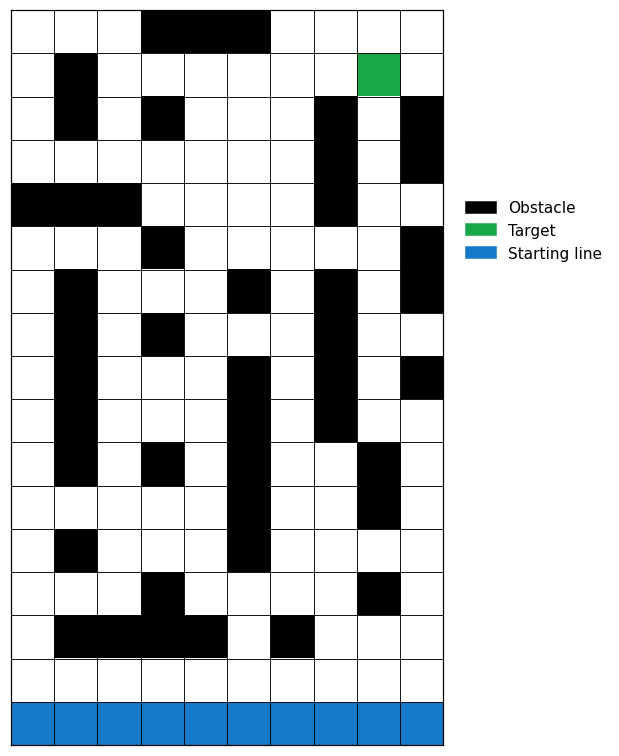

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

grid = np.loadtxt(root / f'data/grids/{grid_name}.csv', delimiter=',', dtype=int)

cmap = ListedColormap(['white', 'black', '#18a84a', '#1479c9'])

def cell_linewidth(grid):
    return max(0.35, min(0.8, 10 / max(grid.shape)))

def grid_figure_size(grid):
    return (
        min(10.5, max(6.5, grid.shape[1] * 0.34 + 1.8)),
        min(8.5, max(5.5, grid.shape[0] * 0.34 + 1.2)),
    )

def draw_grid(ax, grid, cmap):
    ax.imshow(grid, cmap=cmap, vmin=0, vmax=3, origin='upper', interpolation='nearest')
    line_width = cell_linewidth(grid)
    for x in range(grid.shape[1] + 1):
        ax.axvline(x - 0.5, color='black', linewidth=line_width, zorder=5)
    for y in range(grid.shape[0] + 1):
        ax.axhline(y - 0.5, color='black', linewidth=line_width, zorder=5)
    ax.set_xlim(-0.5, grid.shape[1] - 0.5)
    ax.set_ylim(grid.shape[0] - 0.5, -0.5)
    ax.set_aspect('equal')
    ax.tick_params(which='both', bottom=False, left=False, labelbottom=False, labelleft=False)

fig, ax = plt.subplots(figsize=grid_figure_size(grid), dpi=110)
draw_grid(ax, grid, cmap)

legend = [
    Patch(facecolor='black', edgecolor='black', label='Obstacle'),
    Patch(facecolor='#18a84a', edgecolor='#18a84a', label='Target'),
    Patch(facecolor='#1479c9', edgecolor='#1479c9', label='Starting line'),
]
ax.legend(handles=legend, loc='center left', bbox_to_anchor=(1.02, 0.7), frameon=False)
fig.tight_layout()
plt.show()

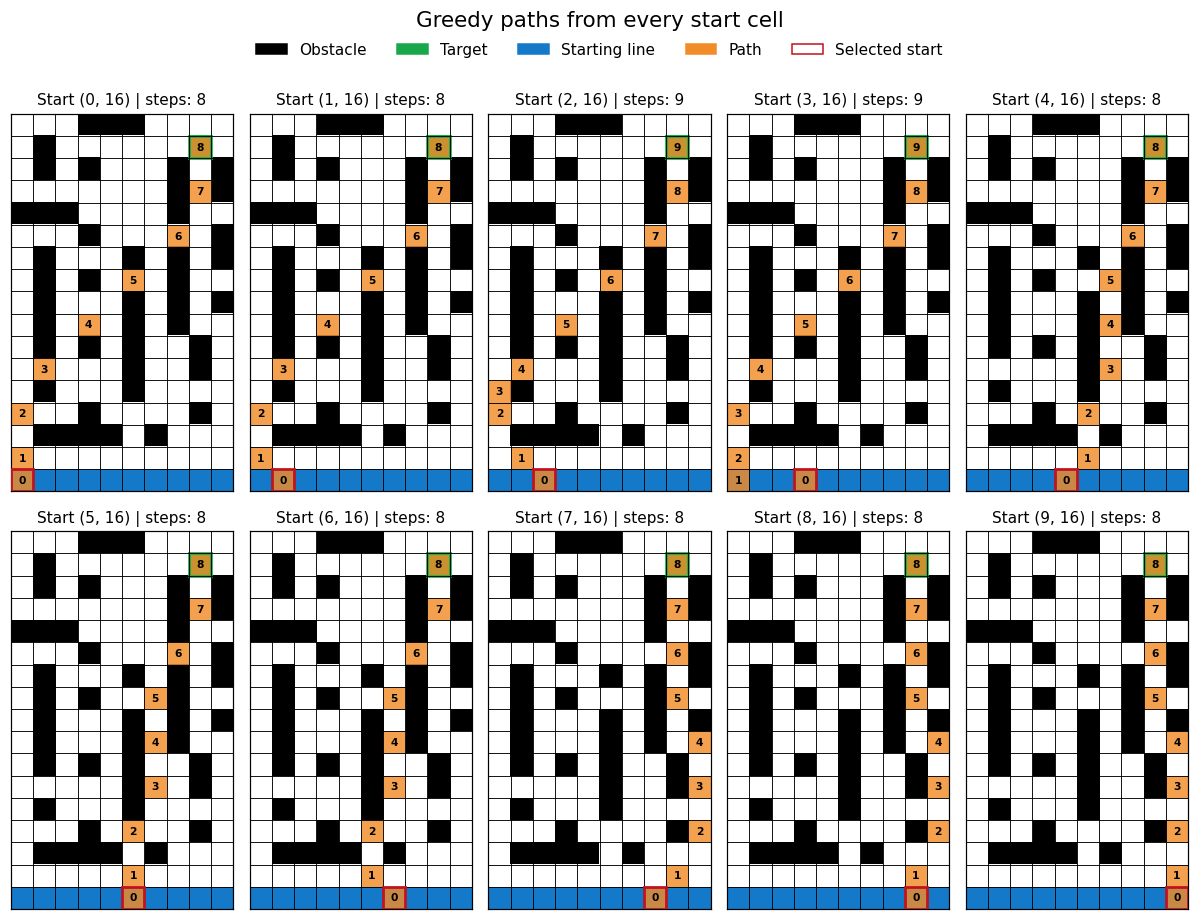

In [11]:
import sys
import pickle
import pandas as pd

if str(root) not in sys.path:
    sys.path.append(str(root))

from src.environment import GridEnvironment
from src.policy import greedy_policy

with q_file.open('rb') as file:
    q = pickle.load(file)

env = GridEnvironment(root / f'data/grids/{grid_name}.csv')
max_steps = env.width * env.height * 100

def greedy_path_from_start(env, q, start_cell, max_steps):
    state = (*start_cell, 0, 0)
    path = [state]

    for _ in range(max_steps):
        action = greedy_policy(state, q)
        state, _, done = env.step(state, action)
        path.append(state)

        if done:
            return path

    return None

start_cells = sorted(env.start_cells, key=lambda cell: (cell[1], cell[0]))
path_by_start = {}
steps_records = []

for start_cell in start_cells:
    path_states = greedy_path_from_start(env, q, start_cell, max_steps)
    path_by_start[start_cell] = path_states
    steps_records.append(
        {
            'start_x': start_cell[0],
            'start_y': start_cell[1],
            'steps': len(path_states) - 1 if path_states is not None else pd.NA,
        }
    )

steps_df = pd.DataFrame(steps_records)

if grid_name == 'grid_3':
    ncols = 4
else:
    ncols = 5

nrows = int(np.ceil(len(start_cells) / ncols))
subplot_w = min(5.2, grid.shape[1] * 0.22)
subplot_h = grid.shape[0] * 0.22 + 0.4

fig, axes = plt.subplots(nrows, ncols, figsize=(subplot_w * ncols, subplot_h * nrows), dpi=110)
axes = np.atleast_1d(axes).ravel()
show_step_numbers = grid.shape[0] <= 18 and grid.shape[1] <= 18
target_cells = {(x, y) for y, x in np.argwhere(grid == 2)}

for ax, start_cell in zip(axes, start_cells):
    path_states = path_by_start[start_cell]
    draw_grid(ax, grid, cmap)

    if path_states is not None:
        path_cells = [(x, y) for x, y, _, _ in path_states]
        for step, (x, y) in enumerate(path_cells):
            is_target_cell = (x, y) in target_cells
            ax.add_patch(plt.Rectangle((x - 0.5, y - 0.5), 1, 1, facecolor='#f28c28', edgecolor='#18a84a' if is_target_cell else 'none', linewidth=2 if is_target_cell else 0, alpha=0.82, zorder=2))
            if show_step_numbers:
                ax.text(x, y, str(step), ha='center', va='center', color='black', fontsize=7, fontweight='bold', zorder=6)

    ax.add_patch(plt.Rectangle((start_cell[0] - 0.5, start_cell[1] - 0.5), 1, 1, facecolor='none', edgecolor='#c1121f', linewidth=1.8, zorder=7))
    steps_value = steps_df.loc[(steps_df['start_x'] == start_cell[0]) & (steps_df['start_y'] == start_cell[1]), 'steps'].iloc[0]
    steps_label = 'NA' if pd.isna(steps_value) else int(steps_value)
    ax.set_title(f'Start {start_cell} | steps: {steps_label}', fontsize=10)

for ax in axes[len(start_cells):]:
    ax.axis('off')

legend = [
    Patch(facecolor='black', edgecolor='black', label='Obstacle'),
    Patch(facecolor='#18a84a', edgecolor='#18a84a', label='Target'),
    Patch(facecolor='#1479c9', edgecolor='#1479c9', label='Starting line'),
    Patch(facecolor='#f28c28', edgecolor='#f28c28', label='Path'),
    Patch(facecolor='none', edgecolor='#c1121f', label='Selected start'),
]
fig.legend(handles=legend, loc='upper center', ncol=5, frameon=False, bbox_to_anchor=(0.5, 1.01))
fig.suptitle('Greedy paths from every start cell', fontsize=14, y=1.03)
fig.tight_layout()
plt.show()

In [12]:
display(steps_df.set_index('start_x')[['steps']])

,steps
start_x,
0,8
1,8
2,9
3,9
4,8
5,8
6,8
7,8
8,8
